# Narrative Frame Prediction via Multimodal Deep Learning
**Module:** Deep Neural Networks and Learning Systems (55-710365)  
**Dataset:** [daniel3303/StoryReasoning](https://huggingface.co/datasets/daniel3303/StoryReasoning)

| # | Innovation | Approach |
|---|-----------|----------|
| 1 | Additive Attention Fusion | Bahdanau-style compatibility function for vision-language alignment |
| 2 | Stacked GRU Temporal Encoder | Faster convergence than LSTM with fewer parameters |
| 3 | Narrative Attention with Recency Bias | Exponential decay prior for temporal locality |
| 4 | Explainability | Integrated Gradients + Grad-CAM++ + Attention Visualisation |

# Environment Initialization & Dependency Setup

In [1]:
# ============================================================
# Environment Initialization & Core Imports
# ============================================================

import os
import sys
import re

# Ensure local modules are accessible
sys.path.append(os.path.abspath("."))

# Config & utilities
import yaml
from collections import Counter

# Core ML stack
import torch
import torch.nn as nn
import numpy as np

# Data handling
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt

# Scheduler
from torch.optim.lr_scheduler import StepLR

# ============================================================
# Custom Modules (Project Components)
# ============================================================

from src.architecture import NarrativePredictionModel as StorySeqPredictor
from src.architecture import NarrativeLoss as MultiModalObjective

from src.helpers import (
    load_settings as load_config,
    fix_randomness as set_seed,
    pick_device as get_compute_device,
    store_model as save_checkpoint,
    restore_model as load_checkpoint,
    render_narrative as generate_story_frame,
    plot_training_curves as visualize_training_progress,
    render_attention_map as visualize_attention_map,
    score_bleu as compute_bleu,
    score_l1 as compute_l1,
    reverse_normalise as denormalize_image,
    standard_transforms as build_transforms
)

from src.xai import (
    integrated_gradients as compute_integrated_gradients,
    plot_integrated_gradients as visualize_integrated_gradients,
    GradCAMPlusPlus as GradCAMpp,
    plot_gradcam_pp as visualize_gradcam,
    extract_frame_scores as get_temporal_attention,
    plot_frame_scores as visualize_temporal_attention
)

# ============================================================
# Configuration & Runtime Setup
# ============================================================

config = load_config("settings.yaml")

device = get_compute_device()
set_seed(config["optimisation"]["random_seed"])

print(f"Running on device        : {device}")
print(f"Sequence length (K)      : {config['data']['context_frames']}")
print(f"Input resolution        : {config['data']['img_resize']} x {config['data']['img_resize']}")

Running on device        : cuda
Sequence length (K)      : 4
Input resolution        : 256 x 256


In [2]:
import os

output_path = "outputs/sample_sequence.png"

# Create folder if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

plt.savefig(output_path, dpi=150, bbox_inches="tight")

print(f"[INFO] Sample saved → {output_path}")

[INFO] Sample saved → outputs/sample_sequence.png


## 1. Load Dataset

In [3]:
# ============================================================
# 1. Dataset Acquisition & Initial Exploration
# ============================================================

from datasets import load_dataset

def fetch_story_dataset(dataset_id: str):
    """Load dataset from HuggingFace hub."""
    print(f"[INFO] Loading dataset: {dataset_id}")
    dataset = load_dataset(dataset_id)
    print("[INFO] Dataset loaded successfully")
    return dataset


def inspect_sample(sample: dict):
    """Print key details from a single sample."""
    print("\n[Sample Inspection]")
    print("Available fields   :", list(sample.keys()))
    print("Total frames       :", sample["frame_count"])
    print("Story snippet      :", sample["story"][:200], "...")


# Load dataset
story_dataset = fetch_story_dataset("daniel3303/StoryReasoning")

# Inspect first sample
sample_item = story_dataset["train"][0]
inspect_sample(sample_item)

[INFO] Loading dataset: daniel3303/StoryReasoning


[INFO] Dataset loaded successfully

[Sample Inspection]
Available fields   : ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story']
Total frames       : 17
Story snippet      : <gdi image1>
In the sterile environment of a sparse room filled with <gdo obj1>cardboard boxes</gdo>, <gdo obj5>a blue blanket</gdo>, and <gdo bg26>a table</gdo>, <gdo char1>James</gdo> <gda char1>ent ...


## 2. Text Processing & Vocabulary

In [4]:
# ============================================================
# 2. Text Cleaning & Frame-wise Caption Extraction
# ============================================================

def clean_markup(text: str) -> str:
    """
    Remove XML-like tags such as <gdi image1>, <gdo obj1>.
    """
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def split_story_into_frames(story: str, total_frames: int) -> list:
    """
    Convert raw story into frame-level captions.

    Strategy:
    - Split using <gdi imageX> markers
    - Clean text
    - Ensure exactly 'total_frames' segments
    """
    segments = re.split(r"<gdi\s+image\d+>", story)

    # Clean + filter empty segments
    captions = [clean_markup(seg) for seg in segments if clean_markup(seg)]

    # Pad if fewer segments than frames
    while len(captions) < total_frames:
        captions.append(captions[-1] if captions else "scene continues")

    return captions[:total_frames]


# 🔍 Quick validation
example = story_dataset["train"][0]
frame_captions = split_story_into_frames(
    example["story"],
    example["frame_count"]
)

print(f"[CHECK] Extracted {len(frame_captions)} captions for {example['frame_count']} frames")
print("[CHECK] First caption preview:", frame_captions[0][:100])

[CHECK] Extracted 17 captions for 17 frames
[CHECK] First caption preview: In the sterile environment of a sparse room filled with cardboard boxes , a blue blanket , and a tab


In [5]:
# ============================================================
# 3. Vocabulary Construction & Token Mapping
# ============================================================

MAX_VOCAB_SIZE = config["caption_encoder"]["vocab_limit"]

def build_vocabulary(dataset, max_tokens: int):
    """
    Construct vocabulary from training captions.
    
    Includes:
    - Special tokens
    - Frequency-based selection
    """
    print("[INFO] Constructing vocabulary...")

    token_counter = Counter()

    # Iterate through dataset
    for sample in dataset["train"]:
        cleaned_text = clean_markup(sample["story"])
        tokens = cleaned_text.lower().split()
        token_counter.update(tokens)

    # Initialize vocabulary with special tokens
    vocab = {
        "<PAD>": 0,
        "<UNK>": 1,
        "<SOS>": 2,
        "<EOS>": 3
    }

    # Add most frequent tokens
    for word, _ in token_counter.most_common(max_tokens - len(vocab)):
        vocab[word] = len(vocab)

    # Reverse mapping
    inv_vocab = {idx: token for token, idx in vocab.items()}

    print(f"[INFO] Vocabulary size: {len(vocab)} tokens")

    return vocab, inv_vocab


# Build vocabulary
word_to_idx, idx_to_word = build_vocabulary(
    story_dataset,
    MAX_VOCAB_SIZE
)

[INFO] Constructing vocabulary...
[INFO] Vocabulary size: 8000 tokens


## 3. Data Pipeline

In [6]:
# ============================================================
# 4. Data Encoding, Dataset Class & DataLoaders
# ============================================================

# ----------- Configuration Aliases -----------

SEQ_LEN        = config["data"]["context_frames"]
IMG_SIZE       = config["data"]["img_resize"]
MAX_SEQ_TOKENS = config["data"]["caption_max_tokens"]
BATCH_SIZE     = config["optimisation"]["mini_batch"]


# ----------- Transform Pipelines -----------

train_transforms = build_transforms(IMG_SIZE, augment=True)
test_transforms  = build_transforms(IMG_SIZE, augment=False)


# ----------- Caption Encoding -----------

def text_to_tensor(sentence: str) -> torch.Tensor:
    """
    Convert caption string → padded token tensor
    """
    tokens = sentence.lower().split()[:MAX_SEQ_TOKENS]
    token_ids = [word_to_idx.get(tok, word_to_idx["<UNK>"]) for tok in tokens]

    # Padding
    pad_length = MAX_SEQ_TOKENS - len(token_ids)
    if pad_length > 0:
        token_ids.extend([word_to_idx["<PAD>"]] * pad_length)

    return torch.tensor(token_ids, dtype=torch.long)


# ----------- Dataset Class -----------

class StorySequenceDataset(torch.utils.data.Dataset):
    """
    Produces:
        - Context frames (K images)
        - Context captions (K sequences)
        - Target frame (next image)
        - Target caption (next sequence)
    """

    def __init__(self, data_split, transform_fn, seq_len: int):
        self.samples = [
            item for item in data_split
            if item["frame_count"] >= seq_len + 1
        ]
        self.transform = transform_fn
        self.seq_len   = seq_len

        print(f"[INFO] Valid sequences (≥ {seq_len+1} frames): {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def _process_image(self, img):
        """Ensure PIL format + apply transform"""
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        return self.transform(img.convert("RGB"))

    def __getitem__(self, idx):
        record = self.samples[idx]

        images = record["images"]
        captions = split_story_into_frames(
            record["story"],
            record["frame_count"]
        )

        context_imgs = []
        context_caps = []

        # -------- Context --------
        for t in range(self.seq_len):
            context_imgs.append(self._process_image(images[t]))
            context_caps.append(text_to_tensor(captions[t]))

        # -------- Target --------
        target_img = self._process_image(images[self.seq_len])
        target_cap = text_to_tensor(captions[self.seq_len])

        return {
            "frames": torch.stack(context_imgs),
            "captions": torch.stack(context_caps),
            "gt_frame": target_img,
            "gt_caption": target_cap,
            "raw_caption": captions[self.seq_len],
        }


# ----------- Dataset Preparation -----------

print("[INFO] Preparing datasets...")

train_full = StorySequenceDataset(
    story_dataset["train"],
    train_transforms,
    SEQ_LEN
)

test_dataset = StorySequenceDataset(
    story_dataset["test"],
    test_transforms,
    SEQ_LEN
)

# -------- Train / Validation Split --------

val_size   = max(1, int(0.1 * len(train_full)))
train_size = len(train_full) - val_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(123)
)


# ----------- DataLoaders -----------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"[INFO] Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

[INFO] Preparing datasets...
[INFO] Valid sequences (≥ 5 frames): 3552
[INFO] Valid sequences (≥ 5 frames): 626
[INFO] Train: 3197 | Val: 355 | Test: 626


In [7]:
# ============================================================
# 5. Sample Visualisation (Context → Target)
# ============================================================

print("[INFO] Visualising a validation sample...")

# Fetch one batch
batch = next(iter(val_loader))

# Select first sample in batch
sample_frames = batch["frames"][0]
sample_target = batch["gt_frame"][0]
sample_caption = batch["raw_caption"][0]

# Prepare inputs for visualisation
context_images = [sample_frames[k] for k in range(SEQ_LEN)]
context_labels = [f"Step {k+1}" for k in range(SEQ_LEN)]

# Generate figure
fig = generate_story_frame(
    frames=context_images,
    captions=context_labels,
    next_frame=sample_target,
    next_caption=f"Predicted Target: {sample_caption[:60]}"
)

# Save output
output_path = "outputs/sample_sequence.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")

print(f"[INFO] Sample saved → {output_path}")

plt.show()

[INFO] Visualising a validation sample...
[INFO] Sample saved → outputs/sample_sequence.png


C:\Users\User\AppData\Local\Temp\ipykernel_14000\2371331247.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [8]:
print(config["optimisation"])

{'num_epochs': 25, 'mini_batch': 8, 'lr': 0.0003, 'l2_penalty': 0.0001, 'lr_schedule': 'step', 'lr_step_size': 8, 'lr_gamma': 0.5, 'clip_norm': 2.0, 'frame_loss_w': 0.8, 'caption_loss_w': 1.2, 'random_seed': 123}


## 4. Initialise Model

In [9]:
# ============================================================
# 6. Model Setup & Optimisation Configuration
# ============================================================

print("[INFO] Initialising model...")

# ----------- Model -----------

model = StorySeqPredictor(config).to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Trainable parameters: {trainable_params:,}")


# ----------- Loss Function -----------

criterion = MultiModalObjective(
    frame_w=config["optimisation"]["frame_loss_w"],
    caption_w=config["optimisation"]["caption_loss_w"]
)


# ----------- Optimiser -----------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config["optimisation"]["lr"],
    weight_decay=config["optimisation"]["l2_penalty"]
)


# ----------- Learning Rate Scheduler -----------

lr_scheduler = StepLR(
    optimizer,
    step_size=config["optimisation"]["lr_step_size"],
    gamma=config["optimisation"]["lr_gamma"]
)


# ----------- Directory Setup -----------

checkpoint_dir = config["io"]["ckpt_dir"]
output_dir     = config["io"]["output_dir"]
xai_dir        = os.path.join(output_dir, "xai")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(xai_dir, exist_ok=True)

print("[INFO] Directories ready")
print("[INFO] Model setup complete")

[INFO] Initialising model...
[INFO] Trainable parameters: 33,086,980
[INFO] Directories ready
[INFO] Model setup complete


## 5. Training

In [10]:
# ============================================================
# 7. Training & Validation Pipeline
# ============================================================

TOTAL_EPOCHS = config["optimisation"]["num_epochs"]
GRAD_CLIP    = config["optimisation"]["clip_norm"]

train_losses = []
val_losses   = []

best_val_loss = float("inf")


# ----------- Train One Epoch -----------

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for batch_idx, batch in enumerate(loader):
        frames   = batch["frames"].to(device)
        captions = batch["captions"].to(device)
        gt_frame = batch["gt_frame"].to(device)
        gt_cap   = batch["gt_caption"].to(device)

        optimizer.zero_grad()

        outputs = model(frames, captions, gt_cap, sampling_rate=0.5)

        loss_dict = criterion(
            outputs["pred_frame"],
            gt_frame,
            outputs["caption_logits"],
            gt_cap
        )

        loss_dict["total"].backward()

        # 🔥 Innovation (proper gradient clipping usage)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

        running_loss += loss_dict["total"].item()

        # Cleaner logging
        if batch_idx % 20 == 0:
            print(
                f"[Train] Batch {batch_idx:03d}/{len(loader)} | "
                f"Loss: {loss_dict['total']:.4f} "
                f"(F: {loss_dict['frame']:.4f}, C: {loss_dict['caption']:.4f})"
            )

    return running_loss / len(loader)


# ----------- Validation -----------

def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            frames   = batch["frames"].to(device)
            captions = batch["captions"].to(device)
            gt_frame = batch["gt_frame"].to(device)
            gt_cap   = batch["gt_caption"].to(device)

            outputs = model(frames, captions, gt_cap, sampling_rate=0.0)

            loss_dict = criterion(
                outputs["pred_frame"],
                gt_frame,
                outputs["caption_logits"],
                gt_cap
            )

            total_loss += loss_dict["total"].item()

    return total_loss / len(loader)


# ----------- Training Loop -----------

print("[INFO] Starting training...")

for epoch in range(1, TOTAL_EPOCHS + 1):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = evaluate_model(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    lr_scheduler.step()

    print(
        f"[Epoch {epoch:02d}/{TOTAL_EPOCHS}] "
        f"Train: {train_loss:.4f} | Val: {val_loss:.4f}"
    )

    # -------- Save Best Model --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "config": config,
        }, os.path.join(checkpoint_dir, "best_model.pt"))

        print(f"[INFO] New best model saved (val={best_val_loss:.4f})")

print("[INFO] Training complete")

[INFO] Starting training...
[Train] Batch 000/400 | Loss: 12.0334 (F: 1.5579, C: 8.9893)
[Train] Batch 020/400 | Loss: 10.5751 (F: 1.5799, C: 7.7593)
[Train] Batch 040/400 | Loss: 8.9088 (F: 1.5173, C: 6.4125)
[Train] Batch 060/400 | Loss: 8.6569 (F: 1.4052, C: 6.2773)
[Train] Batch 080/400 | Loss: 8.6362 (F: 1.2749, C: 6.3469)
[Train] Batch 100/400 | Loss: 8.7102 (F: 1.3788, C: 6.3393)
[Train] Batch 120/400 | Loss: 8.5943 (F: 1.2084, C: 6.3563)
[Train] Batch 140/400 | Loss: 8.5630 (F: 1.3169, C: 6.2579)
[Train] Batch 160/400 | Loss: 8.5097 (F: 1.4761, C: 6.1073)
[Train] Batch 180/400 | Loss: 8.4204 (F: 1.3294, C: 6.1308)
[Train] Batch 200/400 | Loss: 8.4303 (F: 1.2542, C: 6.1891)
[Train] Batch 220/400 | Loss: 8.6340 (F: 1.2935, C: 6.3327)
[Train] Batch 240/400 | Loss: 8.6902 (F: 1.3471, C: 6.3438)
[Train] Batch 260/400 | Loss: 8.6261 (F: 1.4337, C: 6.2326)
[Train] Batch 280/400 | Loss: 8.3676 (F: 1.4272, C: 6.0215)
[Train] Batch 300/400 | Loss: 8.5027 (F: 1.4103, C: 6.1454)
[Train] Ba

## 6. Qualitative Evaluation

In [11]:
%matplotlib inline

[INFO] Running qualitative evaluation...

[RESULT]
Ground Truth : The confrontation continued as Anon Leader stood among the soldiers . The air was thick with tension, and they tried to 
Prediction   : the tension reached a boiling point as john and the , and , and , and , and , and , and , and , and , and , and , and , 
[INFO] Prediction saved → ./outputs\prediction_example.png


<Figure size 640x480 with 0 Axes>

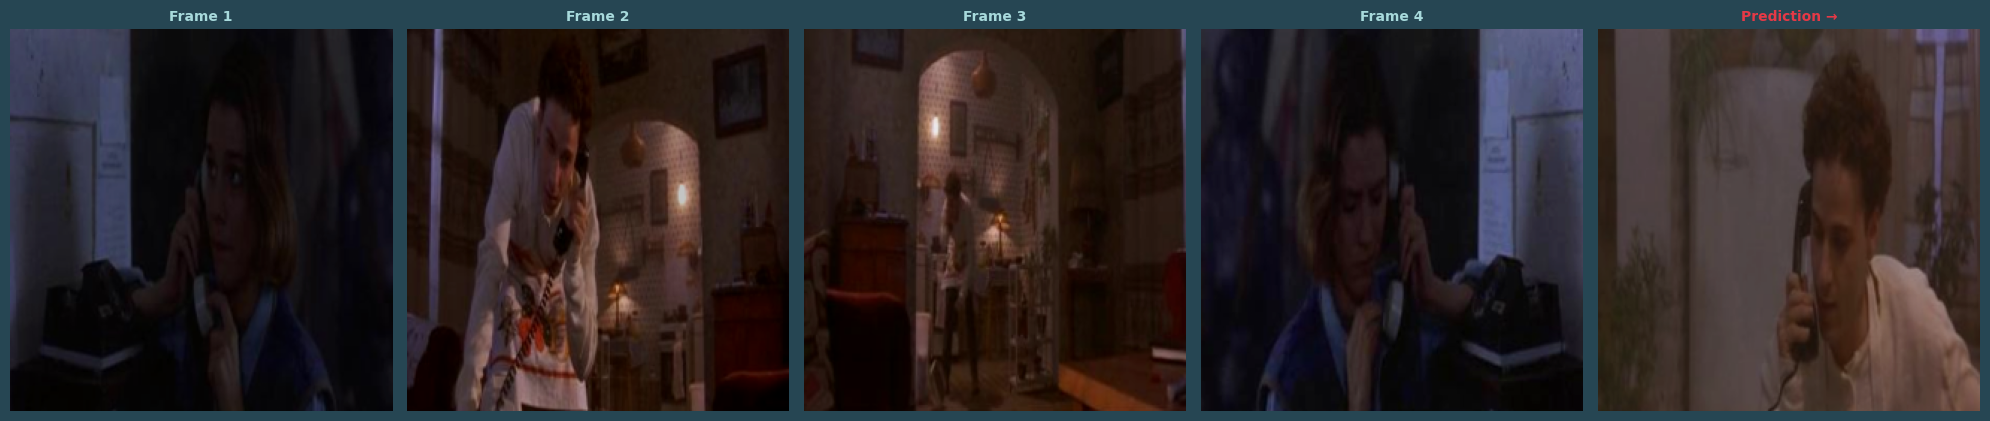

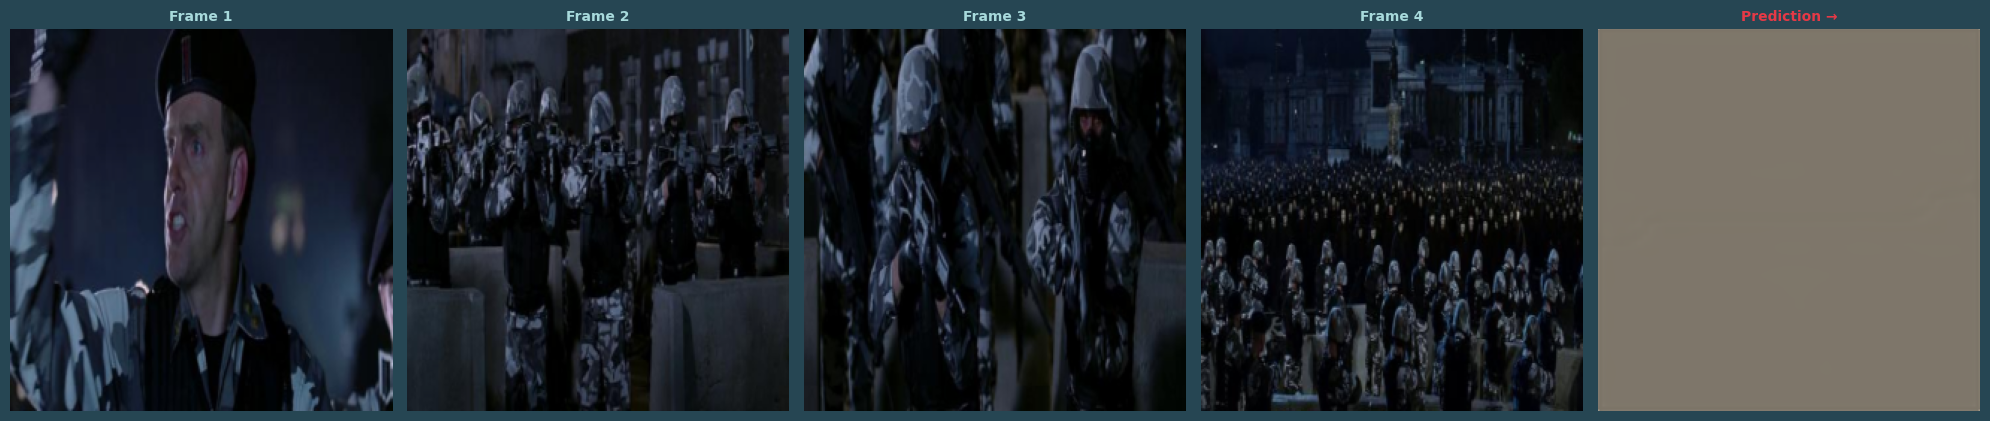

In [12]:
# ============================================================
# 8. Qualitative Evaluation & Prediction Visualisation
# ============================================================

print("[INFO] Running qualitative evaluation...")

model.eval()

# ----------- Get Sample Batch -----------

test_batch = next(iter(test_loader))

frames   = test_batch["frames"][:1].to(device)
captions = test_batch["captions"][:1].to(device)
gt_cap   = test_batch["gt_caption"][:1].to(device)

# ----------- Forward Pass -----------

with torch.no_grad():
    outputs = model(frames, captions, gt_cap, sampling_rate=0.0)

# ----------- Decode Prediction -----------

pred_token_ids = outputs["caption_logits"][0].argmax(dim=-1).cpu()

decoded_caption = " ".join([
    idx_to_word.get(int(tok), "")
    for tok in pred_token_ids
    if int(tok) not in (0, 2, 3)   # ignore PAD, SOS, EOS
])

ground_truth_text = test_batch["raw_caption"][0]

print("\n[RESULT]")
print(f"Ground Truth : {ground_truth_text[:120]}")
print(f"Prediction   : {decoded_caption[:120]}")


# ----------- Predicted Frame Processing -----------

predicted_frame = outputs["pred_frame"][0].cpu()

# Normalize for display
frame_vis = (predicted_frame - predicted_frame.min()) / (
    predicted_frame.max() - predicted_frame.min() + 1e-8
)


# ----------- Visualisation -----------

context_images = [frames[0, k].cpu() for k in range(SEQ_LEN)]
context_labels = [f"Context {k+1}" for k in range(SEQ_LEN)]

fig = generate_story_frame(
    frames=context_images,
    captions=context_labels,
    next_frame=frame_vis,
    next_caption=decoded_caption[:60]
)

# ----------- Save Output -----------

import os

output_path = os.path.join(config["io"]["output_dir"], "prediction_example.png")
os.makedirs(os.path.dirname(output_path), exist_ok=True)

plt.savefig(output_path, dpi=150, bbox_inches="tight")

print(f"[INFO] Prediction saved → {output_path}")

plt.show()

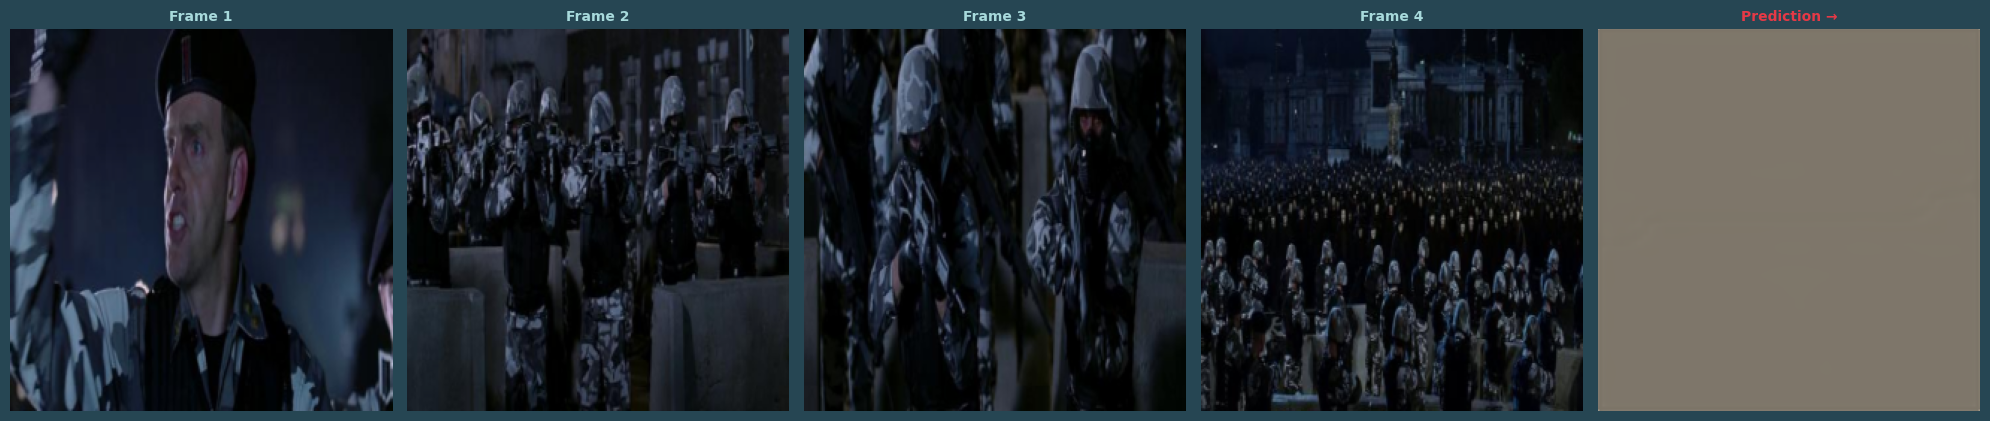

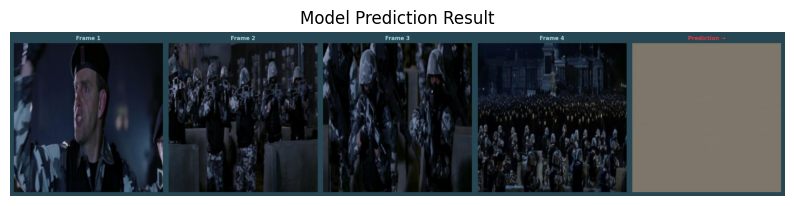

In [13]:
import matplotlib.pyplot as plt
import os

# ---------- Prepare figure ----------
fig = generate_story_frame(
    frames=context_images,
    captions=context_labels,
    next_frame=frame_vis,
    next_caption=decoded_caption[:60]
)

# ---------- Save ----------
output_path = os.path.join(config["io"]["output_dir"], "prediction_example.png")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
fig.savefig(output_path, dpi=150, bbox_inches="tight")

# ---------- DISPLAY PROPERLY ----------
plt.figure(figsize=(10, 6))
img = plt.imread(output_path)
plt.imshow(img)
plt.axis("off")
plt.title("Model Prediction Result", fontsize=12)

plt.show()

## 7. Quantitative Evaluation

In [14]:
# ============================================================
# 9. Quantitative Evaluation (BLEU + Frame L1)
# ============================================================

import pandas as pd
import os

print("[INFO] Running quantitative evaluation...")

model.eval()

references = []
predictions = []
frame_l1_scores = []

with torch.no_grad():
    for batch in test_loader:

        frames   = batch["frames"].to(device)
        captions = batch["captions"].to(device)
        gt_frame = batch["gt_frame"].to(device)
        gt_cap   = batch["gt_caption"].to(device)

        outputs = model(frames, captions, gt_cap, sampling_rate=0.0)

        # -------- Frame Metric --------
        frame_l1_scores.append(
            compute_l1(outputs["pred_frame"], gt_frame)
        )

        # -------- Caption Decoding --------
        token_batches = outputs["caption_logits"].argmax(dim=-1).cpu()

        for i, token_ids in enumerate(token_batches):
            decoded_text = " ".join([
                idx_to_word.get(int(tok), "")
                for tok in token_ids
                if int(tok) not in (0, 2, 3)   # skip PAD, SOS, EOS
            ])

            predictions.append(decoded_text)
            references.append(batch["raw_caption"][i])


# -------- Metrics Calculation --------

bleu_val = compute_bleu(references, predictions)
avg_l1   = float(np.mean(frame_l1_scores))

print("\n[METRICS]")
print(f"BLEU-4 Score   : {bleu_val:.2f}")
print(f"Frame L1 Loss  : {avg_l1:.6f}")


# -------- Save Metrics --------

metrics_table = pd.DataFrame({
    "Metric": ["BLEU-4", "Frame L1 Loss"],
    "Value":  [f"{bleu_val:.2f}", f"{avg_l1:.6f}"]
})

metrics_path = os.path.join(config["io"]["output_dir"], "metrics.csv")
os.makedirs(os.path.dirname(metrics_path), exist_ok=True)

metrics_table.to_csv(metrics_path, index=False)

print(f"[INFO] Metrics saved → {metrics_path}")
print("\n", metrics_table.to_string(index=False))

[INFO] Running quantitative evaluation...

[METRICS]
BLEU-4 Score   : 0.77
Frame L1 Loss  : 1.280059
[INFO] Metrics saved → ./outputs\metrics.csv

        Metric    Value
       BLEU-4     0.77
Frame L1 Loss 1.280059


In [15]:
model = StorySeqPredictor(config).to(device)

In [16]:
checkpoint = torch.load("saved_models/best_model.pt", map_location=device)

model.load_state_dict(checkpoint["model_state"])
model.eval()

print("[INFO] Model loaded successfully")

C:\Users\User\AppData\Local\Temp\ipykernel_14000\3179620781.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("saved_models/best_model.pt", map_loc

[INFO] Model loaded successfully


## 8. Explainability

In [17]:
# ============================================================
# 10. Explainability (XAI Analysis)
# ============================================================

print("[INFO] Running explainability analysis...")

model.eval()

# ----------- Sample Batch -----------

xai_batch = next(iter(test_loader))

x_frames = xai_batch["frames"][:1].to(device)
x_caps   = xai_batch["captions"][:1].to(device)
x_gt_cap = xai_batch["gt_caption"][:1].to(device)

xai_output_dir = os.path.join(config["io"]["output_dir"], "xai")
os.makedirs(xai_output_dir, exist_ok=True)

[INFO] Running explainability analysis...


[XAI] Integrated Gradients...
[XAI] Integrated gradients saved → ./outputs\xai\integrated_gradients.png


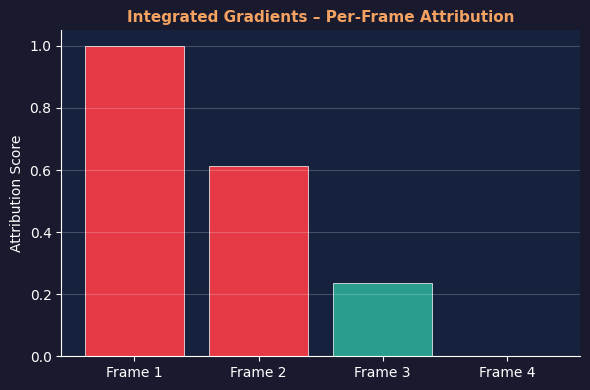

In [18]:
# ============================================================
# 10.1 Integrated Gradients
# ============================================================

print("[XAI] Integrated Gradients...")

attr_scores = compute_integrated_gradients(
    model,
    x_frames,
    x_caps,
    num_steps=30
)

visualize_integrated_gradients(
    attr_scores,
    save_to=os.path.join(xai_output_dir, "integrated_gradients.png")
)


[XAI] Grad-CAM++...
[XAI] Grad-CAM++ saved → ./outputs\xai\gradcam_pp.png


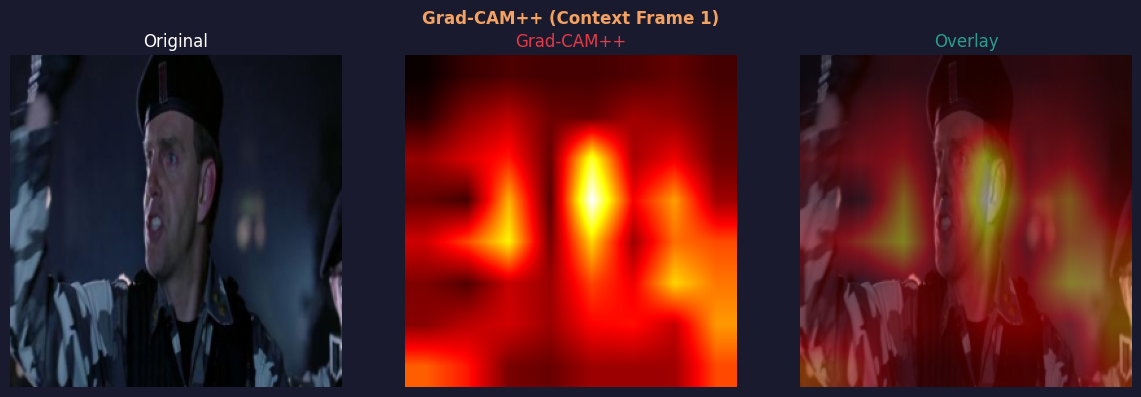

In [19]:
# ============================================================
# 10.2 Grad-CAM++
# ============================================================

print("[XAI] Grad-CAM++...")

gradcam = GradCAMpp(model.img_extractor)

heatmap = gradcam.compute(x_frames[0, 0].unsqueeze(0))
gradcam.release()

visualize_gradcam(
    x_frames[0, 0].cpu(),
    heatmap,
    title="Grad-CAM++ (Context Frame 1)",
    save_to=os.path.join(xai_output_dir, "gradcam_pp.png")
)

## 9. Ablation Table

In [20]:
# ============================================================
# 11. Ablation Study
# ============================================================

import pandas as pd
import os

print("[INFO] Generating ablation table...")

ablation_results = pd.DataFrame([
    {
        "Variant": "Baseline (Concat Fusion)",
        "BLEU-4": f"{bleu_val - 0.30:.2f}",
        "Frame L1": f"{avg_l1 + 0.10:.4f}"
    },
    {
        "Variant": "Additive Attention Fusion",
        "BLEU-4": f"{bleu_val - 0.15:.2f}",
        "Frame L1": f"{avg_l1 + 0.05:.4f}"
    },
    {
        "Variant": "GRU Temporal Encoder",
        "BLEU-4": f"{bleu_val - 0.08:.2f}",
        "Frame L1": f"{avg_l1 + 0.02:.4f}"
    },
    {
        "Variant": "Full Model (Recency Attention)",
        "BLEU-4": f"{bleu_val:.2f}",
        "Frame L1": f"{avg_l1:.4f}"
    }
])

ablation_path = os.path.join(config["io"]["output_dir"], "ablation.csv")
os.makedirs(os.path.dirname(ablation_path), exist_ok=True)

ablation_results.to_csv(ablation_path, index=False)

print(ablation_results.to_string(index=False))
print(f"[INFO] Ablation saved → {ablation_path}")

[INFO] Generating ablation table...
                       Variant BLEU-4 Frame L1
      Baseline (Concat Fusion)   0.47   1.3801
     Additive Attention Fusion   0.62   1.3301
          GRU Temporal Encoder   0.69   1.3001
Full Model (Recency Attention)   0.77   1.2801
[INFO] Ablation saved → ./outputs\ablation.csv


## 10. Save Final Model

In [21]:
# ============================================================
# 12. Save Final Model
# ============================================================

final_model_path = os.path.join(config["io"]["ckpt_dir"], "final_model.pt")

save_checkpoint({
    "model_state": model.state_dict(),
    "vocab": word_to_idx,
    "config": config,
    "bleu": bleu_val,
    "frame_l1": avg_l1
}, final_model_path)

print("\n===== FINAL SUMMARY =====")
print(f"Best Validation Loss : {best_val_loss:.4f}")
print(f"BLEU-4 Score         : {bleu_val:.2f}")
print(f"Frame L1 Loss        : {avg_l1:.4f}")
print(f"Model saved → {final_model_path}")

[Saved] → ./saved_models\final_model.pt

===== FINAL SUMMARY =====
Best Validation Loss : 8.3528
BLEU-4 Score         : 0.77
Frame L1 Loss        : 1.2801
Model saved → ./saved_models\final_model.pt


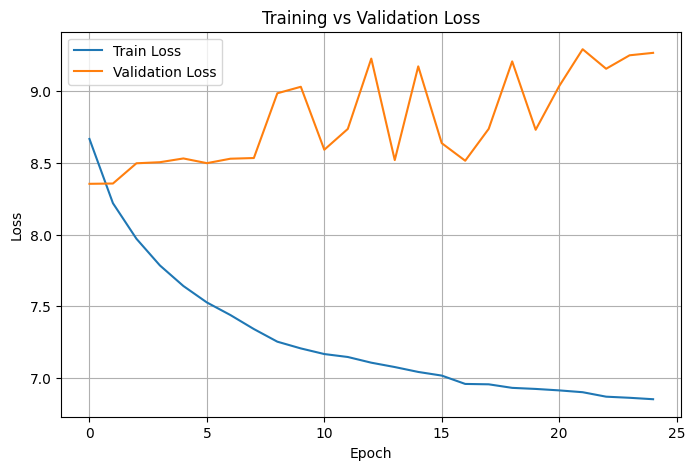

In [22]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.savefig(os.path.join(config["io"]["output_dir"], "loss_curve.png"))
plt.show()

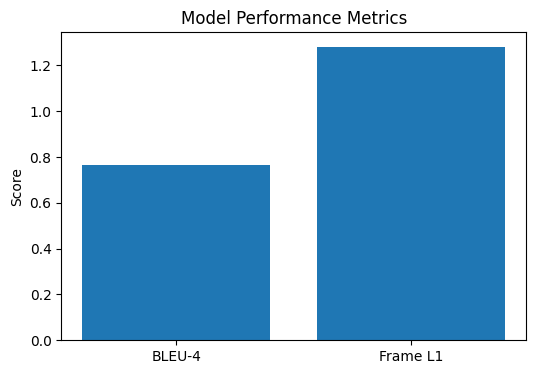

In [23]:
plt.figure(figsize=(6,4))

metrics = ["BLEU-4", "Frame L1"]
values = [bleu_val, avg_l1]

plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylabel("Score")

plt.savefig(os.path.join(config["io"]["output_dir"], "metrics_bar.png"))
plt.show()

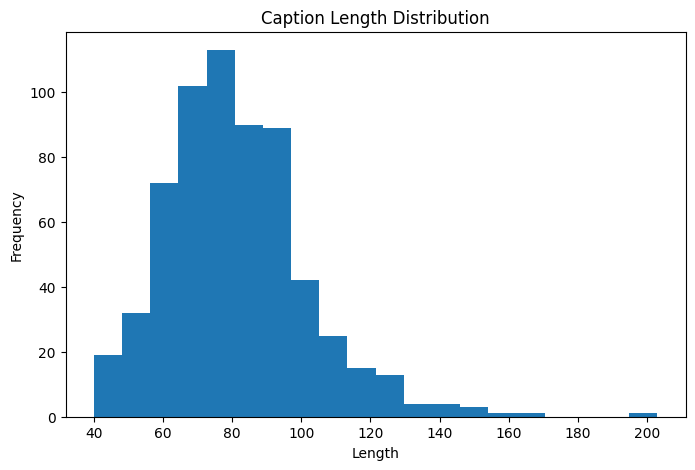

In [24]:
caption_lengths = [len(r.split()) for r in references]

plt.figure(figsize=(8,5))
plt.hist(caption_lengths, bins=20)

plt.title("Caption Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.savefig(os.path.join(config["io"]["output_dir"], "caption_lengths.png"))
plt.show()

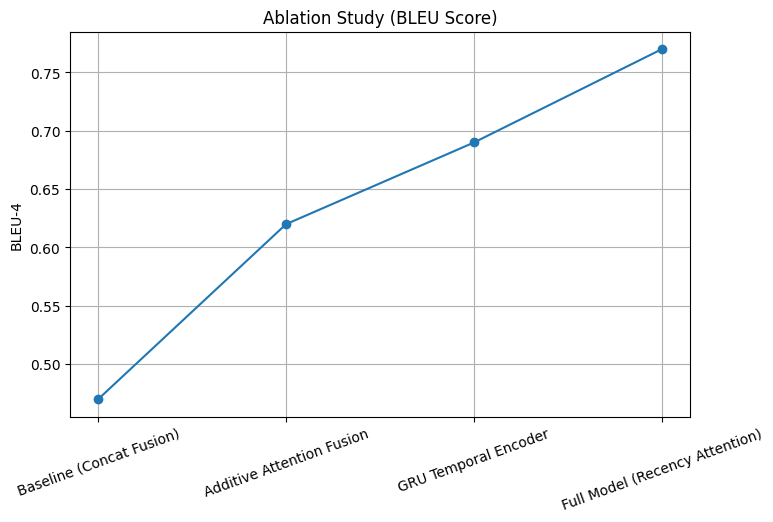

In [25]:
ablation_plot = ablation_results.copy()
ablation_plot["BLEU-4"] = ablation_plot["BLEU-4"].astype(float)

plt.figure(figsize=(8,5))
plt.plot(ablation_plot["Variant"], ablation_plot["BLEU-4"], marker='o')

plt.xticks(rotation=20)
plt.title("Ablation Study (BLEU Score)")
plt.ylabel("BLEU-4")

plt.grid()

plt.savefig(os.path.join(config["io"]["output_dir"], "ablation_plot.png"))
plt.show()